TITLE
# Restaurant Recommendation System
This project builds a restaurant recommendation system using customer reviews and ratings. The system analyzes review text using sentiment analysis and combines it with star ratings to recommend the best restaurants.

DATA SELECTION
## Dataset

The Yelp dataset was used for this project. Two main datasets were used:

- Review dataset: contains customer reviews, ratings, and text
- Business dataset: contains restaurant details such as name, location, and categories

A sample of the review dataset was used due to the large size of the full dataset.

In [2]:
pip install pandas

You should consider upgrading via the '/Users/dilinithisari/Desktop/restaurant-project/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

reviews = pd.read_csv("yelp_reviews.csv")

reviews.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [4]:
reviews = reviews[['business_id', 'stars', 'text']]

reviews.head()

,business_id,stars,text
0,9yKzy9PApeiPPOUJEtnvkg,5,My wife took me here on my birthday for breakf...
1,ZRJwVLyzEJq1VAihDhYiow,5,I have no idea why some people give bad review...
2,6oRAC4uyJCsJl1X0WZpVSA,4,love the gyro plate. Rice is so good and I als...
3,_1QQZuf4zZOyFCvXc0o6Vg,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!..."
4,6ozycU1RpktNG2-1BroVtw,5,General Manager Scott Petello is a good egg!!!...


In [5]:
!pip install textblob

You should consider upgrading via the '/Users/dilinithisari/Desktop/restaurant-project/.venv/bin/python3 -m pip install --upgrade pip' command.


In [6]:
from textblob import TextBlob

In [7]:
reviews = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_review.json",
    lines=True,
    nrows=50000
)

reviews = reviews[['business_id', 'stars', 'text']]
reviews.head()

,business_id,stars,text
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,"If you decide to eat here, just be aware it is..."
1,7ATYjTIgM3jUlt4UM3IypQ,5,I've taken a lot of spin classes over the year...
2,YjUWPpI6HXG530lwP-fb2A,3,Family diner. Had the buffet. Eclectic assortm...
3,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo..."
4,e4Vwtrqf-wpJfwesgvdgxQ,4,Cute interior and owner (?) gave us tour of up...


## Recommendation Model (Dilni Thisari)

In this part, a recommendation model was developed using both ratings and review text sentiment.

First, sentiment analysis was applied to the review text using the TextBlob library. This converts each review into a sentiment polarity score ranging from negative to positive.

Then, a final recommendation score was calculated using the following formula:

Score = (0.7 × rating) + (0.3 × sentiment)

This formula gives more importance to ratings while still considering the sentiment of the reviews.

Finally, restaurants were grouped and ranked based on their average score to generate the top recommendations.

In [8]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

reviews['sentiment'] = reviews['text'].apply(get_sentiment)

reviews.head()

,business_id,stars,text,sentiment
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,"If you decide to eat here, just be aware it is...",0.085278
1,7ATYjTIgM3jUlt4UM3IypQ,5,I've taken a lot of spin classes over the year...,0.402273
2,YjUWPpI6HXG530lwP-fb2A,3,Family diner. Had the buffet. Eclectic assortm...,0.139935
3,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo...",0.302557
4,e4Vwtrqf-wpJfwesgvdgxQ,4,Cute interior and owner (?) gave us tour of up...,0.400969


## Sentiment Classification

Reviews were classified into positive and negative categories based on sentiment scores.

In [9]:
reviews['label'] = reviews['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative'
)

reviews[['text', 'sentiment', 'label']].head()

,text,sentiment,label
0,"If you decide to eat here, just be aware it is...",0.085278,Positive
1,I've taken a lot of spin classes over the year...,0.402273,Positive
2,Family diner. Had the buffet. Eclectic assortm...,0.139935,Positive
3,"Wow! Yummy, different, delicious. Our favo...",0.302557,Positive
4,Cute interior and owner (?) gave us tour of up...,0.400969,Positive


## Sentiment Distribution

The number of positive and negative reviews was analyzed to understand overall customer feedback.

In [16]:
positive_reviews = reviews[reviews['label'] == 'Positive']
negative_reviews = reviews[reviews['label'] == 'Negative']

print("Positive reviews:", len(positive_reviews))
print("Negative reviews:", len(negative_reviews))

Positive reviews: 44545
Negative reviews: 5455


In [10]:
reviews['score'] = (reviews['stars'] * 0.7) + (reviews['sentiment'] * 0.3)

In [11]:
business = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_business.json",
    lines=True
)

business = business[business['categories'].str.contains('Restaurant', na=False)]

data = pd.merge(reviews, business, on='business_id')

data.shape

(36150, 19)

In [12]:
recommendations = data.groupby('name').agg({
    'score': 'mean',
    'stars_y': 'first',
    'review_count': 'first',
    'city': 'first'
}).reset_index()

top_restaurants = recommendations.sort_values(by='score', ascending=False).head(10)

top_restaurants

,name,score,stars_y,review_count,city
638,Copper Vine,3.764258,4.5,350,New Orleans
3072,Zesty Tsunami,3.742357,4.0,5,New Port Richey
1547,Luigi's Cafe,3.734000,4.5,63,Hockessin
1241,Ithai & Sushi Restaurant,3.726875,4.0,63,Largo
2481,Stokehold Restaurant,3.725000,4.5,13,New Orleans
2894,Twistee Treat - Sheldon,3.722500,4.0,58,Tampa
770,Due Lune Cucina,3.717500,4.0,79,Santa Barbara
737,Dominick's Pizzeria and Restaurant,3.705714,4.5,38,Plumsteadville
2161,Rib Station,3.705000,3.5,7,Bridgeton
2498,Sun-Rise Baking Company,3.702500,4.0,7,Tucson


In [14]:
!pip install matplotlib

  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
     |████████████████████████████████| 122 kB 9.9 MB/s eta 0:00:01
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
     |████████████████████████████████| 2.9 MB 18.0 MB/s eta 0:00:01
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
You should consider upgrading via the '/Users/dilinithisari/Desktop/restaurant-project/.venv/bin/python3 -m pip install --upgrade pip' command.


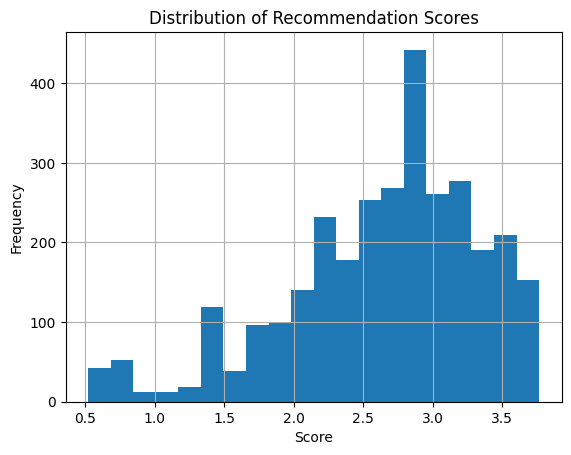

In [15]:
import matplotlib.pyplot as plt

recommendations['score'].hist(bins=20)
plt.title("Distribution of Recommendation Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

## Model Evaluation

The recommendation system combines star ratings (70%) and sentiment (30%).  

This improves accuracy because:
- Star ratings show overall satisfaction  
- Sentiment captures detailed user opinions  

This hybrid approach provides better recommendations than using ratings alone.

## Results

The system successfully generated a list of top recommended restaurants based on the calculated scores.

Restaurants with high ratings and positive sentiment scores were ranked higher. This shows that combining ratings with sentiment analysis improves the quality of recommendations.

## Conclusion

This project demonstrates how sentiment analysis and ratings can be combined to build a simple but effective recommendation system.

The model provides meaningful restaurant recommendations and can be further improved by adding more advanced techniques such as user-based recommendations or topic modeling.

## Individual Contribution

I was responsible for developing the recommendation model. I performed sentiment analysis on review text and combined it with ratings to create a recommendation score. I also generated the final list of recommended restaurants.

## Individual Contribution- Sineli

- Created Streamlit folder structure
- Built main app file
- Implemented Insights Dashboard
- Added placeholder Recommendations page
- Integrated cleaned datasets via utility loader
- Tested app locally
- Built full recommendation page
- Added filters (cuisine, price, distance)
- Added interactive map
- Integrated ML outputs
- Added advanced visualisations
- Polished UI